In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Admin/Downloads/studentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  mathscore  readingscore  writingscore  
0                    none       72.0            72            74  
1               completed       69.0            90            88  
2                    none       90.0            95            93  
3                    none       47.0            57            44  
4                    none       76.0            78            75  


In [2]:
#Check missing values
print(df.isnull().sum())

gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
mathscore                      15
readingscore                    0
writingscore                    0
dtype: int64


In [4]:
#Fill missing values
# Numeric → mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())



In [5]:
#Remove duplicates
df.drop_duplicates(inplace=True)

In [8]:
#Identify Skewness
print(df[num_cols].skew())

mathscore      -0.289526
readingscore   -0.259105
writingscore   -0.289444
dtype: float64


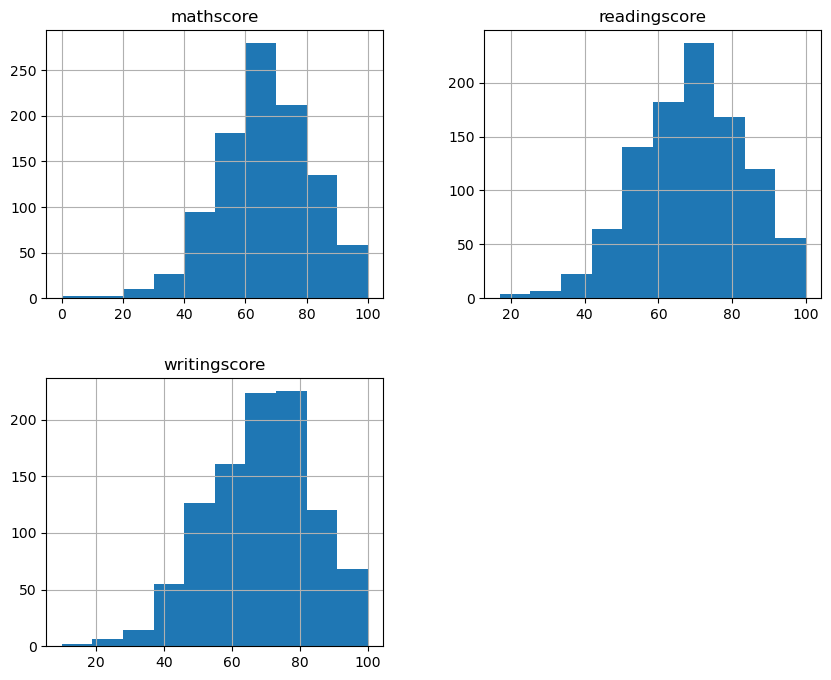

In [7]:
df[num_cols].hist(figsize=(10,8))
plt.show()

In [11]:
#Data Transformation
# Apply log transformation on skewed columns
for col in num_cols:
    if df[col].skew() > 1:   # highly skewed
        df[col] = np.log1p(df[col])

mathscore      -0.289526
readingscore   -0.259105
writingscore   -0.289444
dtype: float64


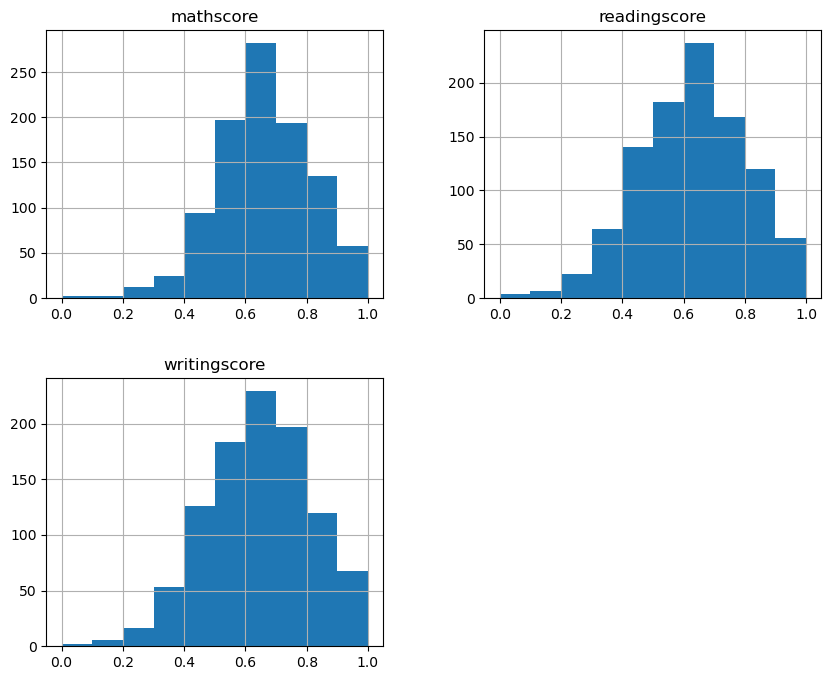

In [14]:
#Verify Skewness After Transformation
print(df[num_cols].skew())

# Plot again
df[num_cols].hist(figsize=(10,8))
plt.show()

In [15]:
#Min-Max Scaling (Change Scale)
for col in num_cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())